In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyrex.core import get_fit_params
from pyrex.basics import read_pkl

/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [ ]:
training_dict = read_pkl("/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/data/pyrexdata.pkl")

{'A_omega': array([0.05191723, 0.09306259, 0.61929377, 0.18497459, 0.04073344,
       0.09095026, 0.17215052, 0.08395883, 0.16136401]), 'B_omega': array([0.00050775, 0.00046974, 0.34538211, 0.00044171, 0.00051871,
       0.00052988, 0.00047805, 0.00058812, 0.00051679]), 'freq_omega': array([ 0.10686718,  0.10667479,  0.21967981, -0.10347665,  0.11840865,
        0.11781496, -0.11426483, -0.13489387, -0.13164821]), 'phi_omega': array([ 0.61830084, -1.91243633, -0.05084704, -0.68955596, -1.67308984,
       -2.14551028,  0.56877482,  2.22971769,  0.69595389]), 'fit_omega': [array([0.0300939 , 0.03001855, 0.02994314, ..., 0.01757074, 0.01753661,
       0.01750234], shape=(15221,)), array([-0.08768417, -0.08762557, -0.08756673, ..., -0.03923753,
       -0.03924837, -0.03925883], shape=(15221,)), array([-3.14756897e-002, -3.25198721e-002, -3.34528370e-002, ...,
       -1.68435427e-274, -1.59052877e-274, -1.50186678e-274],
      shape=(15221,)), array([-0.11767985, -0.11743351, -0.1171869 , .

In [3]:
qs = np.array([1, 1, 1, 1, 2.0, 2.0, 2.0, 3.0, 3.0])
e_ref = np.array([0.053, 0.097, 0.189, 0.192, 0.044, 0.097, 0.185, 0.093, 0.18])

x = (20/(2*np.pi))**(2/3)

# compute the value to colour by for each (q, e)
par_vals = []
for q, e in zip(qs, e_ref):
    par_omega, par_amp = get_fit_params(training_dict, q, e, x)
    par_vals.append(par_omega[0])   # or par_amp[0] depending on what you want
par_vals = np.array(par_vals)

# scatter plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(qs, e_ref, c=par_vals, cmap='cividis', s=80, edgecolor='k', linewidth=0.5)
plt.colorbar(sc, label='par_amp[1]')
plt.xlabel("Mass ratio q")
plt.ylabel("Eccentricity (e_ref)")
plt.title("Reference samples over (q, e_ref) — coloured by par_amp[1]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

12 12 9


ValueError: Expected the first axis of `d` to have length 12.

Clearly interpolation in this way is just going wrong for some reason, there is no reason for the above to look like the situation below when interpolated.

In [ ]:
eccentricities = np.linspace(1e-30, 0.2, 50)
mass_ratios = np.linspace(1, 3, 50)

x = (20/(2*np.pi))**(2/3)

grid = np.zeros((len(mass_ratios), len(eccentricities)))

for i, e in enumerate(eccentricities):
    for j, q in enumerate(mass_ratios):
        par_omega, par_amp = get_fit_params(training_dict, q, e, (20/(2*np.pi))**(2/3))

        grid[i, j] = par_amp[2]

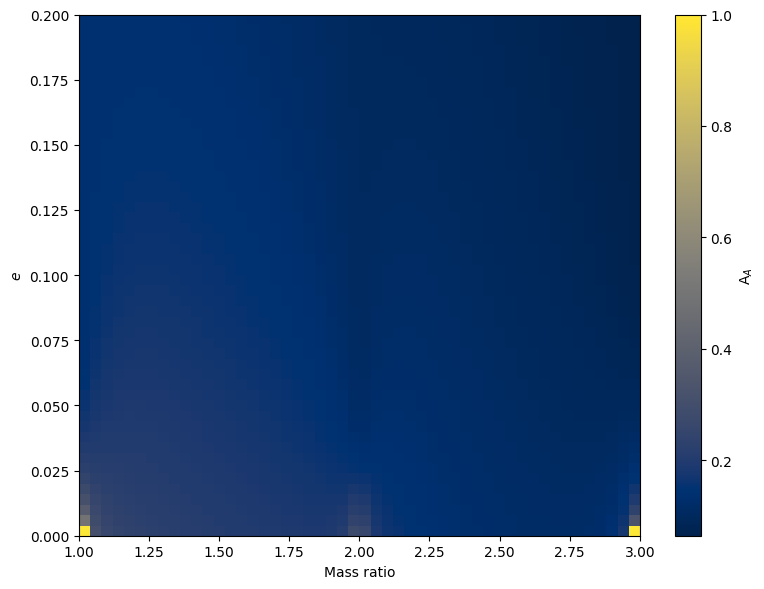

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(grid, origin='lower', aspect='auto',
           extent=[mass_ratios.min(), mass_ratios.max(), 
                   eccentricities.min(), eccentricities.max()],
           cmap='cividis',)
plt.colorbar(label=r"A$_A$")
plt.xlabel(r"Mass ratio")
plt.ylabel(r"$e$")
# plt.title("Mismatch Heatmap: IMRPhenomD Eccentric vs Circular")
plt.tight_layout()
plt.show()